<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Checking dataset paths...
✅ Found: /content/drive/MyDrive/data/train.csv
✅ Found: /content/drive/MyDrive/data/test.csv
✅ Found: /content/drive/MyDrive/data/phiusiil.csv

📥 Loading file: train.csv
➡ Columns before cleaning: ['labels', 'url']
➡ Total rows before cleaning: 160000
➡ Columns after cleaning: ['url', 'labels']
➡ Rows after cleaning: 160000
➡ Label distribution:
 labels
1    80000
0    80000
Name: count, dtype: int64

📥 Loading file: test.csv
➡ Columns before cleaning: ['url', 'labels']
➡ Total rows before cleaning: 160000
➡ Columns after cleaning: ['url', 'labels']
➡ Rows after cleaning: 160000
➡ Label distribution:
 labels
1    80000
0    80000
Name: count, dtype: int64

📥 Loading file: phiusiil.csv
➡ Columns before cleaning: ['URL', 'label']
➡ Total rows before cleaning: 235795
➡ Columns after cleaning: ['url', 'labels']
➡ Rows after cleaning: 

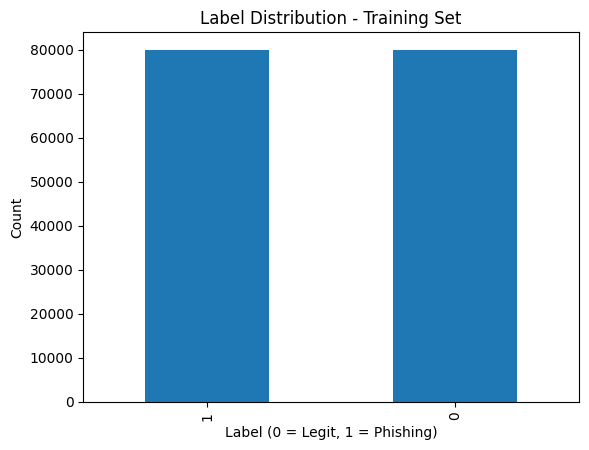


🧠 Vectorization started...
➡ Training shape: (160000, 1115001)
➡ Testing shape: (160000, 1115001)
➡ PhiUSIIL shape: (235795, 1115001)

🚀 Model training started...
✅ Training completed
➡ Iterations: 7

📊 Evaluation on Test Set
Accuracy : 0.93293125
Precision: 0.9108725309923483
Recall   : 0.959775
F1-score : 0.9346845613074044


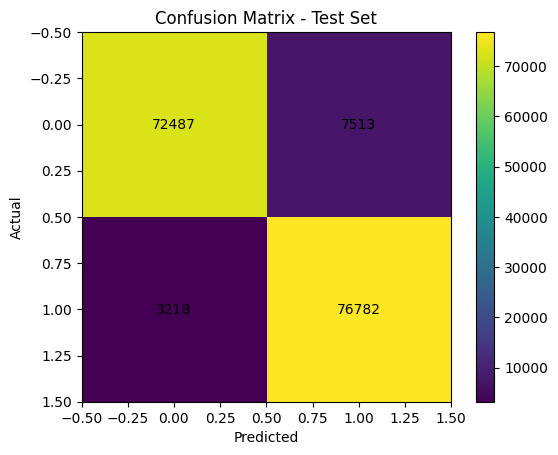

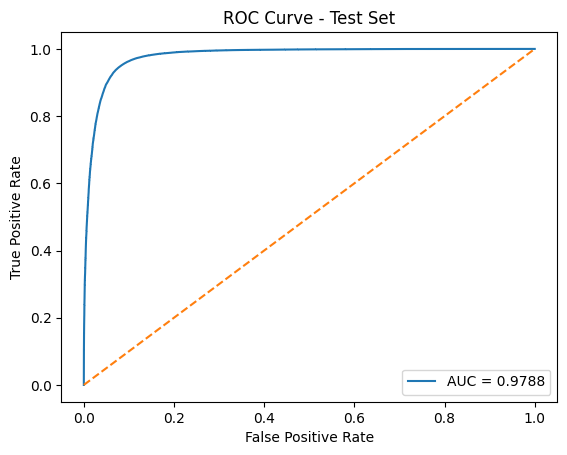

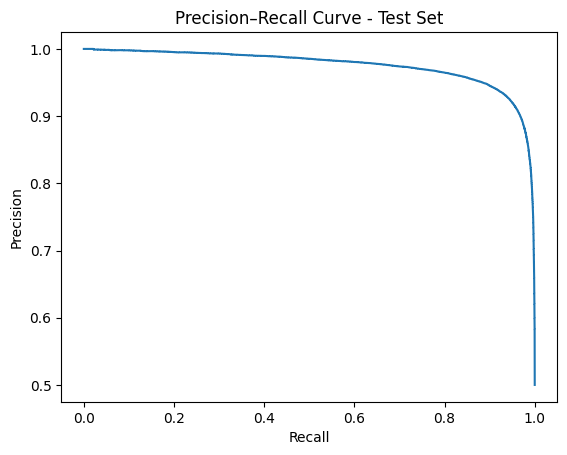


📊 Evaluation on PhiUSIIL External Dataset
Accuracy : 0.767225768146059
Precision: 0.7107228502911956
Recall   : 0.9999925843529848
F1-score : 0.83090099665727


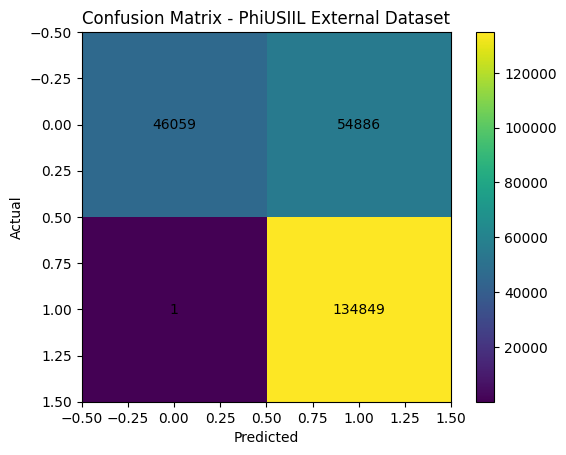

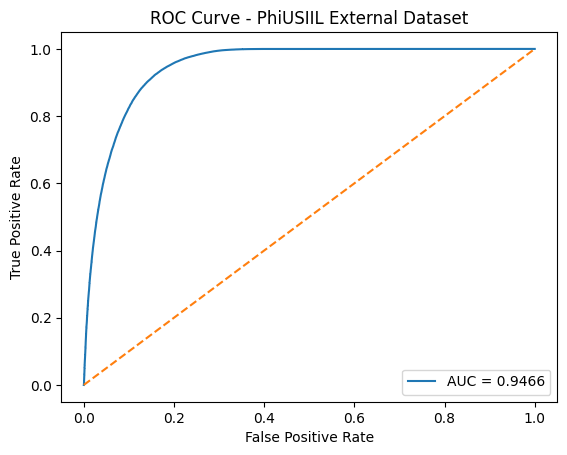

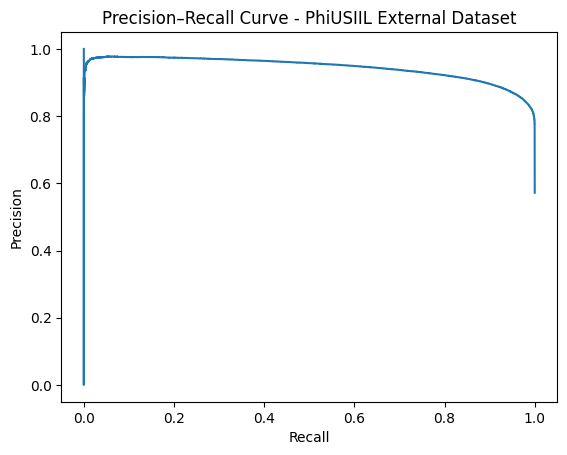

In [3]:
# ======================================
# 1. Mount Google Drive
# ======================================
from google.colab import drive
drive.mount("/content/drive")

# ======================================
# 2. Imports
# ======================================
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# ======================================
# 3. File paths
# ======================================
BASE_PATH = "/content/drive/MyDrive/data"

TRAIN_PATH = os.path.join(BASE_PATH, "train.csv")
TEST_PATH = os.path.join(BASE_PATH, "test.csv")
PHIUSIIL_PATH = os.path.join(BASE_PATH, "phiusiil.csv")

# ======================================
# 4. Safety check
# ======================================
print("\n🔍 Checking dataset paths...")
for path in [TRAIN_PATH, TEST_PATH, PHIUSIIL_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")
    print(f"✅ Found: {path}")

# ======================================
# 5. Load & clean dataset
# ======================================
def load_and_clean(path):
    print(f"\n📥 Loading file: {os.path.basename(path)}")
    df = pd.read_csv(path)

    print("➡ Columns before cleaning:", df.columns.tolist())
    print("➡ Total rows before cleaning:", len(df))

    if os.path.basename(path) == "phiusiil.csv":
        df = df[['URL', 'label']].rename(columns={'URL': 'url', 'label': 'labels'})
    else:
        df = df[['url', 'labels']]

    df.dropna(inplace=True)

    print("➡ Columns after cleaning:", df.columns.tolist())
    print("➡ Rows after cleaning:", len(df))
    print("➡ Label distribution:\n", df['labels'].value_counts())

    return df

train_df = load_and_clean(TRAIN_PATH)
test_df = load_and_clean(TEST_PATH)
phiusiil_df = load_and_clean(PHIUSIIL_PATH)

# ======================================
# 6. Label Distribution Plot
# ======================================
plt.figure()
train_df['labels'].value_counts().plot(kind='bar')
plt.title("Label Distribution - Training Set")
plt.xlabel("Label (0 = Legit, 1 = Phishing)")
plt.ylabel("Count")
plt.show()

# ======================================
# 7. Vectorization
# ======================================
print("\n🧠 Vectorization started...")

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2
)

X_train = vectorizer.fit_transform(train_df['url'])
y_train = train_df['labels']

X_test = vectorizer.transform(test_df['url'])
y_test = test_df['labels']

X_phi = vectorizer.transform(phiusiil_df['url'])
y_phi = phiusiil_df['labels']

print("➡ Training shape:", X_train.shape)
print("➡ Testing shape:", X_test.shape)
print("➡ PhiUSIIL shape:", X_phi.shape)

# ======================================
# 8. Model Training
# ======================================
print("\n🚀 Model training started...")

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    learning_rate="optimal",
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Training completed")
print("➡ Iterations:", model.n_iter_)

# ======================================
# 9. Evaluation + Graphs
# ======================================
def evaluate_and_plot(X, y, name):
    print(f"\n📊 Evaluation on {name}")

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # ---------- ROC Curve ----------
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # ---------- Precision–Recall Curve ----------
    precision, recall, _ = precision_recall_curve(y, y_prob)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve - {name}")
    plt.show()

# ======================================
# 10. Run Evaluation
# ======================================
evaluate_and_plot(X_test, y_test, "Test Set")
evaluate_and_plot(X_phi, y_phi, "PhiUSIIL External Dataset")
